In [ ]:
# Data manipulation
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [1]:
!ls


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
#load dataset from Google sheets using a public link for easy access.

import pandas as pd

file_id = "1AVwaUWzseJdPtRjE5o8mRGeYsyIGqkde"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv"

df = pd.read_csv(url)

df.head()
df.info()
df.describe()

ModuleNotFoundError: No module named 'pandas'

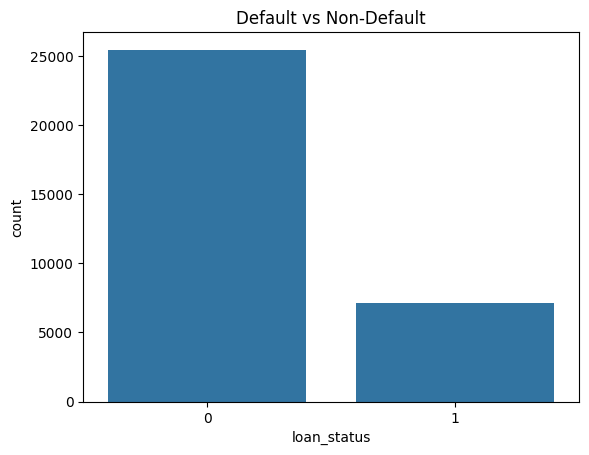

In [65]:
#Visualize loan status distribution to identify patterns.
sns.countplot(x='loan_status', data=df)
plt.title("Default vs Non-Default")
plt.show()

In [66]:
#Check missing values in each column to prepare for data cleaning
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


We found missing values in loan interest rate and employment length, so we handled them using median imputation.

In [67]:
#Filling missing values with the mediam instead of droping data to avoid information
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [68]:
#handling missing values and encoding categorical variables before training.
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y':1, 'N':0})

In [69]:
#created a new feature to improve model performance
df['loan_to_income'] = df['loan_amnt'] / df['person_income']

In [70]:
#separating the features and the target variable.
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [71]:
X = pd.get_dummies(X, drop_first=True)

In [72]:
#split the data into training and testing sets while preserving class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)



In [73]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [75]:

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8749872122762148
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      7642
           1       0.79      0.59      0.67      2133

    accuracy                           0.87      9775
   macro avg       0.84      0.77      0.80      9775
weighted avg       0.87      0.87      0.87      9775

[[7303  339]
 [ 883 1250]]


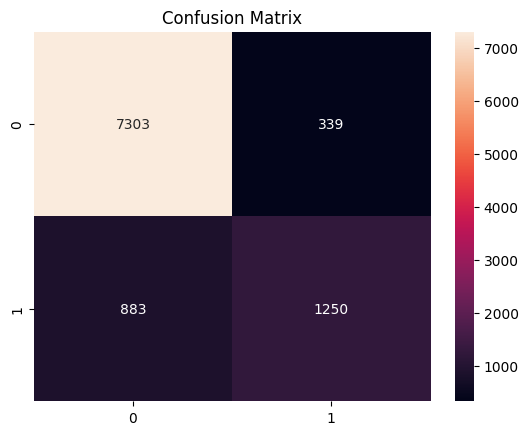

In [76]:


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()